# LMC-Synth coverage with oracle-latent ARIMA and end-to-end VARMA-CSS

## Abstract

This experiment extends the retained TimePFN LMC-Synth AR/VAR study with moving-average terms and regular differencing. The oracle-latent path fits one pooled ARIMA-CSS model to each known latent function and then applies the retained mixing matrix. The end-to-end path fits a pooled vector ARMA-CSS model directly to the four observed channels. Both paths use exactly the mechanisms, trajectories, seeds, metrics, thresholds, and best-configuration rule of the AR/VAR baseline.

In [1]:
from __future__ import annotations

import json
import platform
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import sklearn
from IPython.display import display


def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists() or (candidate / ".git").exists():
            return candidate
    raise FileNotFoundError("Could not locate the repository root.")


REPO_ROOT = find_repo_root(Path.cwd().resolve())
sys.path.insert(0, str(REPO_ROOT / "src"))

from tsfmxai.baselines import fit_pooled_arma, one_step_nmse, simulate_pooled_arma
from tsfmxai.evaluation import (
    DEFAULT_THRESHOLDS,
    channel_metrics,
    distribution_metrics,
    dominant_periods,
    passes_channel_coverage,
    passes_coverage,
    violation_score,
)
from tsfmxai.generators import (
    draw_retained_kernel_case,
    draw_retained_lmc_case,
    retained_kernel_cases,
    retained_lmc_mechanisms,
)

GLOBAL_SEED = 20260930
LENGTH = 1024
N_TRAIN = 16
N_TEST = 16
RIDGE = 1e-5
CSS_ITERATIONS = 4
MAX_ACF_LAG = 64
THRESHOLDS = dict(DEFAULT_THRESHOLDS)
CROSS_CORR_THRESHOLD = 0.10


CONFIGURATIONS = [
    (1, 0, 0), (2, 0, 0), (4, 0, 0), (8, 0, 0),
    (16, 0, 0), (32, 0, 0), (64, 0, 0), (128, 0, 0),
    (1, 0, 1), (2, 0, 1), (4, 0, 1), (8, 0, 1), (2, 1, 1), (4, 1, 1),
]

def configuration_name(order):
    return f"ARIMA{tuple(order)}"

print(f"Configurations: {[configuration_name(item) for item in CONFIGURATIONS]}")

Configurations: ['ARIMA(1, 0, 0)', 'ARIMA(2, 0, 0)', 'ARIMA(4, 0, 0)', 'ARIMA(8, 0, 0)', 'ARIMA(16, 0, 0)', 'ARIMA(32, 0, 0)', 'ARIMA(64, 0, 0)', 'ARIMA(128, 0, 0)', 'ARIMA(1, 0, 1)', 'ARIMA(2, 0, 1)', 'ARIMA(4, 0, 1)', 'ARIMA(8, 0, 1)', 'ARIMA(2, 1, 1)', 'ARIMA(4, 1, 1)']


The same `(p,d,q)` search is used for latent ARIMA and observed-channel VARMA. The `q=0` configurations reproduce the complete AR/VAR order search as a nested control; `q=1` and `d=1` then measure the additional ARIMA/VARMA capacity.

In [2]:
MECHANISMS, BANK, LATENT_FACTORS = retained_lmc_mechanisms(global_seed=GLOBAL_SEED, length=LENGTH)
assert len(MECHANISMS) == 11 and len(BANK) == 33
display(pd.DataFrame([{key: mechanism[key] for key in ["id", "latent_ids", "dirichlet_alpha"]}
                      for mechanism in MECHANISMS]))

,id,latent_ids,dirichlet_alpha
0,lmc_01,"[periodic_01_p24, periodic_02_p48, periodic_03...",0.2
1,lmc_02,"[periodic_04_p168, periodic_05_p336, periodic_...",0.5
2,lmc_03,"[periodic_07_p7, periodic_08_p14, periodic_09_...",1.0
3,lmc_04,"[periodic_10_p60, periodic_11_p365, periodic_1...",2.0
4,lmc_05,"[periodic_13_p4, periodic_14_p26, periodic_15_...",0.2
5,lmc_06,"[periodic_16_p4, periodic_17_p6, periodic_18_p12]",0.5
6,lmc_07,"[periodic_19_p4, periodic_20_p40, periodic_21_...",1.0
7,lmc_08,"[linear_sigma0, linear_sigma1, linear_sigma10]",2.0
8,lmc_09,"[rbf_scale0.1, rbf_scale1, rbf_scale10]",0.2
9,lmc_10,"[rq_alpha0.1, rq_alpha1, rq_alpha10]",0.5


The eleven mechanisms partition all 33 official kernel-bank entries into triples and mix each triple into four observed channels with a retained Dirichlet matrix.

In [3]:
rows = []
reference_series = {}
for mechanism_index, mechanism in enumerate(MECHANISMS):
    data = draw_retained_lmc_case(mechanism, LATENT_FACTORS, mechanism_index=mechanism_index,
                                  global_seed=GLOBAL_SEED, n_train=N_TRAIN, n_test=N_TEST)
    reference_series[mechanism["id"]] = data["test_channels"][0].copy()
    for configuration_index, order in enumerate(CONFIGURATIONS):
        configuration = configuration_name(order)
        latent_fits = [fit_pooled_arma(data["train_latents"][:, latent, :], order=order,
                                       ridge=RIDGE, css_iterations=CSS_ITERATIONS) for latent in range(3)]
        start = max(fit.start for fit in latent_fits)
        generated_latents = np.stack([
            simulate_pooled_arma(
                fit, data["test_latents"][:, latent, :fit.start], length=LENGTH,
                rng=np.random.default_rng(
                    GLOBAL_SEED + 2_000_000 + 10000 * mechanism_index + 100 * order[0] + latent
                    if order[1] == 0 and order[2] == 0
                    else GLOBAL_SEED + 5_000_000 + 10000 * mechanism_index + 100 * configuration_index + latent
                ),
            ) for latent, fit in enumerate(latent_fits)
        ], axis=1)
        raw_latents = generated_latents * data["latent_scales"][None, :, None] + data["latent_means"][None, :, None]
        oracle_raw_channels = np.einsum("cq,nqt->ntc", mechanism["mixing"], raw_latents)
        oracle_channels = (oracle_raw_channels - data["channel_means"]) / data["channel_scales"]
        oracle_metrics = channel_metrics(data["test_channels"], oracle_channels, start, max_acf_lag=MAX_ACF_LAG)
        rows.append({"mechanism": mechanism["id"], "latent_ids": ", ".join(mechanism["latent_ids"]),
                     "model": "oracle_latent_ARIMA", "configuration": configuration, "order": max(order[0], order[2]),
                     "forecast_nmse": float(np.mean([one_step_nmse(fit, data["test_latents"][:, latent, :])
                                                     for latent, fit in enumerate(latent_fits)])),
                     **oracle_metrics, "well_covered": passes_channel_coverage(
                         oracle_metrics, thresholds=THRESHOLDS,
                         cross_correlation_threshold=CROSS_CORR_THRESHOLD)})

        vector_fit = fit_pooled_arma(data["train_channels"], order=order, ridge=RIDGE,
                                     css_iterations=CSS_ITERATIONS)
        vector_channels = simulate_pooled_arma(
            vector_fit, data["test_channels"][:, :vector_fit.start], length=LENGTH,
            rng=np.random.default_rng(
                GLOBAL_SEED + 3_000_000 + 1000 * mechanism_index + order[0]
                if order[1] == 0 and order[2] == 0
                else GLOBAL_SEED + 6_000_000 + 1000 * mechanism_index + configuration_index
            ),
        )
        vector_metrics = channel_metrics(data["test_channels"], vector_channels, vector_fit.start,
                                         max_acf_lag=MAX_ACF_LAG)
        rows.append({"mechanism": mechanism["id"], "latent_ids": ", ".join(mechanism["latent_ids"]),
                     "model": "end_to_end_VARMA", "configuration": configuration, "order": max(order[0], order[2]),
                     "forecast_nmse": one_step_nmse(vector_fit, data["test_channels"]),
                     **vector_metrics, "well_covered": passes_channel_coverage(
                         vector_metrics, thresholds=THRESHOLDS,
                         cross_correlation_threshold=CROSS_CORR_THRESHOLD)})

results = pd.DataFrame(rows)
results["violation_score"] = results.apply(
    lambda row: violation_score(row, thresholds=THRESHOLDS,
                                cross_correlation_threshold=CROSS_CORR_THRESHOLD), axis=1)
best = (results.sort_values(["mechanism", "model", "violation_score", "forecast_nmse", "configuration"])
        .groupby(["mechanism", "model"], as_index=False).first())
status = results.groupby(["mechanism", "model"])["well_covered"].any().rename("well_covered_any_order").reset_index()
best = best.merge(status, on=["mechanism", "model"])
coverage_curve = results.groupby(["model", "configuration"])["well_covered"].mean().unstack(0)
display(best[["mechanism", "model", "configuration", "well_covered_any_order", "acf_mae", "psd_jsd",
              "abs_log_variance_ratio", "standardized_wasserstein", "cross_corr_frobenius"]].round(4))

C:\Users\mateu\repos\tsfmxai\src\tsfmxai\baselines\pooled_arma.py:197: RuntimeWarning: overflow encountered in square
  return float(np.mean((target - predicted) ** 2) / (np.var(target) + 1e-12))


C:\Users\mateu\repos\tsfmxai\.venv\Lib\site-packages\numpy\core\_methods.py:118: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)


C:\Users\mateu\repos\tsfmxai\src\tsfmxai\baselines\pooled_arma.py:154: RuntimeWarning: overflow encountered in matmul
  prediction += residuals[:, time_index - lag] @ coefficient
C:\Users\mateu\repos\tsfmxai\src\tsfmxai\baselines\pooled_arma.py:154: RuntimeWarning: invalid value encountered in matmul
  prediction += residuals[:, time_index - lag] @ coefficient


,mechanism,model,configuration,well_covered_any_order,acf_mae,psd_jsd,abs_log_variance_ratio,standardized_wasserstein,cross_corr_frobenius
0,lmc_01,end_to_end_VARMA,"ARIMA(128, 0, 0)",True,0.0000,0.0000,0.0000,0.0001,0.0000
1,lmc_01,oracle_latent_ARIMA,"ARIMA(128, 0, 0)",True,0.0000,0.0000,0.0000,0.0001,0.0000
2,lmc_02,end_to_end_VARMA,"ARIMA(2, 0, 0)",False,0.0675,0.1672,0.1628,0.1131,0.0475
3,lmc_02,oracle_latent_ARIMA,"ARIMA(4, 0, 1)",False,0.0749,0.1014,0.3253,0.1939,0.0783
4,lmc_03,end_to_end_VARMA,"ARIMA(128, 0, 0)",True,0.0000,0.0000,0.0002,0.0006,0.0001
5,lmc_03,oracle_latent_ARIMA,"ARIMA(128, 0, 0)",True,0.0002,0.0000,0.0003,0.0008,0.0002
6,lmc_04,end_to_end_VARMA,"ARIMA(4, 0, 0)",False,0.0991,0.2456,0.0965,0.0954,0.0180
7,lmc_04,oracle_latent_ARIMA,"ARIMA(4, 0, 0)",False,0.1081,0.2490,0.0472,0.1927,0.0058
8,lmc_05,end_to_end_VARMA,"ARIMA(128, 0, 0)",True,0.0057,0.0000,0.0003,0.0034,0.0008
9,lmc_05,oracle_latent_ARIMA,"ARIMA(128, 0, 0)",True,0.0024,0.0000,0.0016,0.0036,0.0002


Oracle-latent ARIMA tests temporal approximation before mixing. End-to-end VARMA tests temporal and cross-channel approximation together. Both simulations are evaluated after the configuration-dependent initialization prefix.

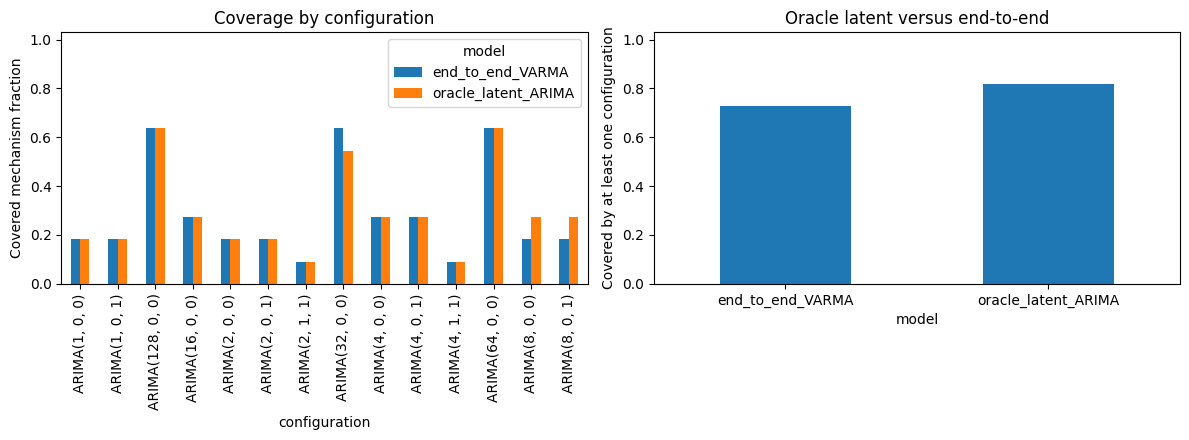

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
coverage_curve.plot.bar(ax=axes[0]); axes[0].set_ylim(0, 1.03)
axes[0].set_ylabel("Covered mechanism fraction"); axes[0].set_title("Coverage by configuration")
best.groupby("model")["well_covered_any_order"].mean().plot.bar(ax=axes[1], rot=0)
axes[1].set_ylim(0, 1.03); axes[1].set_ylabel("Covered by at least one configuration")
axes[1].set_title("Oracle latent versus end-to-end")
fig.tight_layout(); plt.show()

The figures keep the access-mode distinction visible instead of combining oracle latent information with end-to-end observed-channel modeling.

In [5]:
covered_pairs = best.loc[best.well_covered_any_order, ["mechanism", "model"]]
failed_pairs = best.loc[~best.well_covered_any_order, ["mechanism", "model"]]
covered_functions = [f"{row.mechanism} [{row.model}]" for row in covered_pairs.itertuples()]
not_covered_functions = [f"{row.mechanism} [{row.model}]" for row in failed_pairs.itertuples()]
diagnostic_series = []
for row in failed_pairs.itertuples():
    mode = "oracle_latent" if "oracle_latent" in row.model else "end_to_end"
    diagnostic_series.append({"benchmark": "lmc_synth", "mechanism": row.mechanism,
                              "evaluation_mode": mode,
                              "values": reference_series[row.mechanism].tolist()})
print(f"WELL COVERED ({len(covered_functions)}/{len(best)}):")
print("\n".join(f"  - {name}" for name in covered_functions) or "  (none)")
print(f"\nNOT WELL COVERED ({len(not_covered_functions)}/{len(best)}):")
print("\n".join(f"  - {name}" for name in not_covered_functions) or "  (none)")
display(best[["mechanism", "latent_ids", "model", "configuration", "well_covered_any_order"]])

WELL COVERED (17/22):
  - lmc_01 [end_to_end_VARMA]
  - lmc_01 [oracle_latent_ARIMA]
  - lmc_03 [end_to_end_VARMA]
  - lmc_03 [oracle_latent_ARIMA]
  - lmc_05 [end_to_end_VARMA]
  - lmc_05 [oracle_latent_ARIMA]
  - lmc_06 [end_to_end_VARMA]
  - lmc_06 [oracle_latent_ARIMA]
  - lmc_07 [end_to_end_VARMA]
  - lmc_07 [oracle_latent_ARIMA]
  - lmc_08 [end_to_end_VARMA]
  - lmc_08 [oracle_latent_ARIMA]
  - lmc_09 [oracle_latent_ARIMA]
  - lmc_10 [end_to_end_VARMA]
  - lmc_10 [oracle_latent_ARIMA]
  - lmc_11 [end_to_end_VARMA]
  - lmc_11 [oracle_latent_ARIMA]

NOT WELL COVERED (5/22):
  - lmc_02 [end_to_end_VARMA]
  - lmc_02 [oracle_latent_ARIMA]
  - lmc_04 [end_to_end_VARMA]
  - lmc_04 [oracle_latent_ARIMA]
  - lmc_09 [end_to_end_VARMA]


,mechanism,latent_ids,model,configuration,well_covered_any_order
0,lmc_01,"periodic_01_p24, periodic_02_p48, periodic_03_p96",end_to_end_VARMA,"ARIMA(128, 0, 0)",True
1,lmc_01,"periodic_01_p24, periodic_02_p48, periodic_03_p96",oracle_latent_ARIMA,"ARIMA(128, 0, 0)",True
2,lmc_02,"periodic_04_p168, periodic_05_p336, periodic_0...",end_to_end_VARMA,"ARIMA(2, 0, 0)",False
3,lmc_02,"periodic_04_p168, periodic_05_p336, periodic_0...",oracle_latent_ARIMA,"ARIMA(4, 0, 1)",False
4,lmc_03,"periodic_07_p7, periodic_08_p14, periodic_09_p30",end_to_end_VARMA,"ARIMA(128, 0, 0)",True
5,lmc_03,"periodic_07_p7, periodic_08_p14, periodic_09_p30",oracle_latent_ARIMA,"ARIMA(128, 0, 0)",True
6,lmc_04,"periodic_10_p60, periodic_11_p365, periodic_12...",end_to_end_VARMA,"ARIMA(4, 0, 0)",False
7,lmc_04,"periodic_10_p60, periodic_11_p365, periodic_12...",oracle_latent_ARIMA,"ARIMA(4, 0, 0)",False
8,lmc_05,"periodic_13_p4, periodic_14_p26, periodic_15_p52",end_to_end_VARMA,"ARIMA(128, 0, 0)",True
9,lmc_05,"periodic_13_p4, periodic_14_p26, periodic_15_p52",oracle_latent_ARIMA,"ARIMA(128, 0, 0)",True


One observed multivariate reference trajectory is retained for every failed mechanism/access-mode pair so the aggregate notebook can plot only failures shared by all three method families.

In [6]:
def git_output(*args):
    try:
        return subprocess.check_output(["git", *args], cwd=REPO_ROOT, text=True).strip()
    except Exception as exc:
        return f"unavailable: {exc}"

mechanism_manifest = [
    {
        "id": mechanism["id"],
        "latent_ids": mechanism["latent_ids"],
        "latent_formulas": mechanism["latent_formulas"],
        "latent_periods": mechanism["latent_periods"],
        "dirichlet_alpha": mechanism["dirichlet_alpha"],
        "mixing": mechanism["mixing"].tolist(),
    }
    for mechanism in MECHANISMS
]

experiment_record = {
    "experiment_id": "timepfn_lmc_arima_varma_css_coverage_001", "status": "completed",
    "research_question": "Which retained LMC-Synth mechanisms are covered by oracle-latent ARIMA-CSS and end-to-end VARMA-CSS?",
    "hypothesis": "MA terms and differencing improve temporal coverage, while end-to-end cross-channel estimation remains harder than oracle latent access.",
    "configuration": {"length": LENGTH, "n_train": N_TRAIN, "n_test": N_TEST,
                      "orders": [list(item) for item in CONFIGURATIONS], "channels": 4,
                      "latents_per_mechanism": 3, "ridge": RIDGE, "css_iterations": CSS_ITERATIONS,
                      "max_acf_lag": MAX_ACF_LAG, "thresholds": THRESHOLDS,
                      "cross_corr_threshold": CROSS_CORR_THRESHOLD, "mechanisms": mechanism_manifest,
                      "estimator": "pooled scalar/vector conditional sum of squares"},
    "provenance": {"repository": "https://github.com/egetaga/TimePFN",
                   "commit": "e11d5c2982b0e49b87873cbddcb7712641861268",
                   "source": "synthetic_data_generation/LMC_Synth.py", "project_head": git_output("rev-parse", "HEAD")},
    "seed_usage": {"global_seed": GLOBAL_SEED,
                   "policy": "same retained train/test draws as AR/VAR; simulation seed derived per mechanism, configuration, access mode, and latent"},
    "environment": {"python": sys.version, "platform": platform.platform(), "numpy": np.__version__,
                    "scipy": scipy.__version__, "pandas": pd.__version__, "scikit_learn": sklearn.__version__,
                    "hardware": "CPU"},
    "metrics": {"coverage_fraction_by_model_and_configuration": coverage_curve.to_dict(),
                "best_row_per_mechanism_and_model": best.to_dict(orient="records")},
    "covered_functions": covered_functions, "not_well_covered_functions": not_covered_functions,
    "diagnostic_series": diagnostic_series,
    "scientific_summary": f"{len(covered_functions)}/{len(best)} retained mechanism/access-mode pairs were covered by at least one ARIMA/VARMA-CSS configuration.",
    "limitations": ["Eleven retained LMC mechanisms do not exhaust the stochastic prior.",
                    "Operational thresholds need sensitivity analysis.", "No Monte Carlo confidence intervals.",
                    "CSS is a tractable pooled estimator rather than exact maximum-likelihood ARIMA/VARMA."],
    "reproduction": {"command": r".\.venv\Scripts\jupyter.exe nbconvert --to notebook --execute experiments\autoregressive_process_coverage\ARIMA\02_timepfn_lmc_arima_varma_coverage.ipynb --output 02_timepfn_lmc_arima_varma_coverage.ipynb --ExecutePreprocessor.timeout=3600"},
}
print("COMPLETE EXPERIMENT RECORD")
print(json.dumps(experiment_record, indent=2, ensure_ascii=False, default=lambda value: float(value)))

COMPLETE EXPERIMENT RECORD
{
  "experiment_id": "timepfn_lmc_arima_varma_css_coverage_001",
  "status": "completed",
  "research_question": "Which retained LMC-Synth mechanisms are covered by oracle-latent ARIMA-CSS and end-to-end VARMA-CSS?",
  "hypothesis": "MA terms and differencing improve temporal coverage, while end-to-end cross-channel estimation remains harder than oracle latent access.",
  "configuration": {
    "length": 1024,
    "n_train": 16,
    "n_test": 16,
    "orders": [
      [
        1,
        0,
        0
      ],
      [
        2,
        0,
        0
      ],
      [
        4,
        0,
        0
      ],
      [
        8,
        0,
        0
      ],
      [
        16,
        0,
        0
      ],
      [
        32,
        0,
        0
      ],
      [
        64,
        0,
        0
      ],
      [
        128,
        0,
        0
      ],
      [
        1,
        0,
        1
      ],
      [
        2,
        0,
        1
      ],
      [
   

The complete experiment record makes the multivariate comparison reproducible without separate configuration or metrics files.